<a href="https://colab.research.google.com/github/Poojithareddy1092/RL/blob/main/LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#EXPERIMENT 1
import random


def cell_to_pos(cell):
    return ((cell - 1) // 5, (cell - 1) % 5)


def pos_to_cell(row, col):
    return row * 5 + col + 1


# Display Grid
def display_grid(grid):
    print("\nGrid:")
    for row in grid:
        print(" ".join(row))


# User Input
dirt = list(map(int, input("Enter dirt cells (1-25) separated by space: ").split()))

obstacles = list(map(int, input("Enter obstacle cells (1-25) separated by space: ").split()))


# Create 5x5 environment
grid = [["." for i in range(5)] for j in range(5)]

# Place dirt
for d in dirt:
    r, c = cell_to_pos(d)
    grid[r][c] = "D"

# Place obstacles
for o in obstacles:
    r, c = cell_to_pos(o)
    grid[r][c] = "X"

# Starting point
robot = [0, 0]
grid[0][0] = "R"

display_grid(grid)


# MDP Simulation

actions = [(0,1), (1,0), (0,-1), (-1,0)]
# Right, Down, Left, Up

action_names = ["Right", "Down", "Left", "Up"]

visited_dirt = set()
total_reward = 0


print("\nRobot Navigation:")

for step in range(50):

    r, c = robot
    moved = False

    for i, action in enumerate(actions):

        nr = r + action[0]
        nc = c + action[1]

        if 0 <= nr < 5 and 0 <= nc < 5:

            cell = pos_to_cell(nr,nc)

            # Avoid obstacles
            if cell not in obstacles:

                print("Action:", action_names[i])

                robot = [nr,nc]
                moved = True


                # Collect dirt
                if cell in dirt and cell not in visited_dirt:
                    print("Cleaned dirt at cell", cell)
                    visited_dirt.add(cell)
                    total_reward += 1


                break


    if not moved:
        print("No possible movement")
        break


    if len(visited_dirt) == len(dirt):
        print("\nAll dirt cleaned!")
        break


print("\nFinal Position:", pos_to_cell(robot[0],robot[1]))
print("Total Reward:", total_reward)


# Final Grid
final_grid = [["." for i in range(5)] for j in range(5)]

for d in dirt:
    r,c = cell_to_pos(d)
    final_grid[r][c]="D"

for o in obstacles:
    r,c = cell_to_pos(o)
    final_grid[r][c]="X"

final_grid[robot[0]][robot[1]]="R"

display_grid(final_grid)

Enter dirt cells (1-25) separated by space: 2 5 16
Enter obstacle cells (1-25) separated by space: 3 6 9

Grid:
R D X . D
X . . X .
. . . . .
D . . . .
. . . . .

Robot Navigation:
Action: Right
Cleaned dirt at cell 2
Action: Down
Action: Right
Action: Down
Action: Right
Action: Right
Action: Down
Action: Down
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right
Action: Left
Action: Right

Final Position: 25
Total Reward: 1

Grid:
. D X . D
X . . X .
. . . . .
D . . . .
. . . . R


In [ ]:
#EXPERIMENT 2
import numpy as np

r,c=map(int,input("Enter warehouse size: ").split())
n=r*c

print("Cells:")
for i in range(1,n+1):
    print(i,end=" ")
    if i%c==0: print()

items=list(map(int,input("Items: ").split()))
goal=int(input("Goal: "))
obs=list(map(int,input("Obstacles: ").split()))

V=np.zeros(n+1)
actions=[(-1,0),(1,0),(0,-1),(0,1)]

for _ in range(20):
    old=V.copy()
    for s in range(1,n+1):

        if s==goal:
            V[s]=5
            continue

        val=0
        x,y=(s-1)//c,(s-1)%c

        for dx,dy in actions:
            nx,ny=x+dx,y+dy

            if nx<0 or nx>=r or ny<0 or ny>=c:
                ns=s; reward=-2
            else:
                ns=nx*c+ny+1
                reward=2 if ns in items else 0

                if ns in obs:
                    ns=s
                    reward=-2

            val+=0.25*(reward+0.9*old[ns])

        V[s]=val

print("\nValue Function:")
for i in range(1,n+1):
    print(round(V[i],2),end=" ")
    if i%c==0: print()

Enter warehouse size: 3 3
Cells:
1 2 3 
4 5 6 
7 8 9 
Items: 2 5 7
Goal: 9
Obstacles: 4 6

Value Function:
-5.62 -3.9 -5.62 
-2.93 -2.39 -0.83 
-4.46 0.13 5.0 


In [ ]:
#EXPERIMENT 3
import random
import math


prices = list(map(int,input("Enter prices: ").split()))


prob = list(map(float,input("Enter buying probabilities: ").split()))

rounds = 100


# Epsilon Greedy
def epsilon_greedy():
    count=[0]*3
    reward=[0]*3
    total=0

    for _ in range(rounds):
        if random.random()<0.1:
            a=random.randint(0,2)
        else:
            a=reward.index(max(reward))

        sale=random.random()<prob[a]
        r=prices[a] if sale else 0

        count[a]+=1
        reward[a]+=r
        total+=r

    return total


# UCB
def ucb():
    count=[0]*3
    reward=[0]*3
    total=0

    for t in range(1,rounds+1):

        if t<=3:
            a=t-1
        else:
            ucb_values=[
                reward[i]/count[i]+math.sqrt(2*math.log(t)/count[i])
                for i in range(3)
            ]
            a=ucb_values.index(max(ucb_values))

        sale=random.random()<prob[a]
        r=prices[a] if sale else 0

        count[a]+=1
        reward[a]+=r
        total+=r

    return total


# Thompson Sampling
def thompson():
    success=[1]*3
    fail=[1]*3
    total=0

    for _ in range(rounds):

        samples=[
            random.betavariate(success[i],fail[i])
            for i in range(3)
        ]

        a=samples.index(max(samples))

        sale=random.random()<prob[a]
        r=prices[a] if sale else 0

        if sale:
            success[a]+=1
        else:
            fail[a]+=1

        total+=r

    return total


print("Revenue Comparison")
print("Epsilon Greedy:", epsilon_greedy())
print("UCB:", ucb())
print("Thompson Sampling:", thompson())

In [ ]:
#EXPERIMENT 4
import random,math

prices=list(map(int,input("Enter prices: ").split()))
prob=list(map(float,input("Enter buying probabilities: ").split()))
n=int(input("Enter decisions: "))


def run(method):
    c=[0]*len(prices)
    r=[0]*len(prices)
    total=0

    for t in range(1,n+1):
        if method=="E":
            a=random.randrange(len(prices)) if random.random()<0.1 else r.index(max(r))

        elif method=="U":
            a=t-1 if t<=len(prices) else max(range(len(prices)),
            key=lambda i:r[i]/c[i]+math.sqrt(2*math.log(t)/c[i]))

        else:
            a=max(range(len(prices)),
            key=lambda i:random.betavariate(c[i]+1,r[i]+1))

        sale=random.random()<prob[a]
        reward=prices[a] if sale else 0
        c[a]+=1
        r[a]+=reward
        total+=reward

    return total


print("Epsilon Greedy:",run("E"))
print("UCB:",run("U"))
print("Thompson:",run("T"))

Enter prices: 345
Enter buying probabilities: 34
Enter decisions: 10
Epsilon Greedy: 3450
UCB: 3450
Thompson: 3450


In [ ]:
#EXPERIMENT 5
import numpy as np

r,c=map(int,input("Grid size: ").split())
n=r*c

print("Cells:")
for i in range(1,n+1):
    print(i,end=" ")
    if i%c==0: print()

goal=int(input("Delivery point: "))
obs=list(map(int,input("Obstacles: ").split()))

V=np.zeros(n+1)
policy=[0]*(n+1)
moves=[(-1,0),(1,0),(0,-1),(0,1)]

for _ in range(20):

    # Policy Evaluation
    for _ in range(10):
        for s in range(1,n+1):
            if s==goal: V[s]=10; continue
            x,y=(s-1)//c,(s-1)%c
            a=policy[s]
            nx,ny=x+moves[a][0],y+moves[a][1]

            if nx<0 or nx>=r or ny<0 or ny>=c or (nx*c+ny+1) in obs:
                V[s]=-1
            else:
                V[s]=-1+0.9*V[nx*c+ny+1]

    # Policy Improvement
    stable=True
    for s in range(1,n+1):
        if s==goal: continue

        old=policy[s]
        vals=[]

        x,y=(s-1)//c,(s-1)%c
        for a in range(4):
            nx,ny=x+moves[a][0],y+moves[a][1]
            if 0<=nx<r and 0<=ny<c and nx*c+ny+1 not in obs:
                vals.append(V[nx*c+ny+1])
            else:
                vals.append(-99)

        policy[s]=np.argmax(vals)

        if old!=policy[s]:
            stable=False

    if stable: break


print("\nOptimal Policy:")
for i in range(1,n+1):
    print(["U","D","L","R"][policy[i]],end=" ")
    if i%c==0: print()

Grid size: 4 4
Cells:
1 2 3 4 
5 6 7 8 
9 10 11 12 
13 14 15 16 
Delivery point: 11
Obstacles: 12 6 8

Optimal Policy:
D R D L 
D D D L 
R R U L 
U U U L 


In [ ]:
#EXPERIMENT-6
import numpy as np

r,c=map(int,input("Grid size: ").split())
n=r*c

print("Cells:")
for i in range(1,n+1):
    print(i,end=" ")
    if i%c==0: print()

pickup=int(input("Pickup point: "))
obs=list(map(int,input("Obstacles: ").split()))

V=np.zeros(n+1)
moves=[(-1,0),(1,0),(0,-1),(0,1)]
policy=[0]*(n+1)

for _ in range(50):

    old=V.copy()

    for s in range(1,n+1):

        if s==pickup:
            V[s]=10
            continue

        x,y=(s-1)//c,(s-1)%c
        vals=[]

        for dx,dy in moves:
            nx,ny=x+dx,y+dy

            if 0<=nx<r and 0<=ny<c and nx*c+ny+1 not in obs:
                ns=nx*c+ny+1
                vals.append(-1+0.9*old[ns])
            else:
                vals.append(-1)

        V[s]=max(vals)
        policy[s]=np.argmax(vals)


print("\nOptimal Dispatch Policy:")
for i in range(1,n+1):
    print(["U","D","L","R"][policy[i]],end=" ")
    if i%c==0: print()

Grid size: 3 4
Cells:
1 2 3 4 
5 6 7 8 
9 10 11 12 
Pickup point: 2
Obstacles: 6 7

Optimal Dispatch Policy:
R U L L 
U U U U 
U L L U 


In [ ]:
#EXPERIMENT-7
import random,math

ads=int(input("Number of ads: "))
prob=list(map(float,input("Click probabilities: ").split()))
n=int(input("Number of rounds: "))


def run(method):
    clicks=[0]*ads
    count=[0]*ads
    total=0

    for t in range(1,n+1):

        if method=="E":
            a=random.randrange(ads) if random.random()<0.1 else clicks.index(max(clicks))

        elif method=="U":
            a=t-1 if t<=ads else max(range(ads),
            key=lambda i:clicks[i]/count[i]+math.sqrt(2*math.log(t)/count[i]))

        else:
            a=max(range(ads),
            key=lambda i:random.betavariate(clicks[i]+1,count[i]-clicks[i]+1))


        click=random.random()<prob[a]

        if click:
            clicks[a]+=1
            total+=1

        count[a]+=1

    return total/n


print("\nClick Through Rate:")
print("Epsilon Greedy:",round(run("E"),3))
print("UCB:",round(run("U"),3))
print("Thompson Sampling:",round(run("T"),3))

Number of ads: 3
Click probabilities: 0.3 0.7 0.4
Number of rounds: 34

Click Through Rate:
Epsilon Greedy: 0.353
UCB: 0.559
Thompson Sampling: 0.618


Grid size: 4 4
Cells:
1 2 3 4 
5 6 7 8 
9 10 11 12 
13 14 15 16 
Delivery point: 12
Obstacles: 2 5 8

State Value Function:
-1.0	3.12	4.58	3.12	
3.12	4.58	6.2	8.0	
4.58	6.2	8.0	10.0	
3.12	4.58	6.2	8.0	


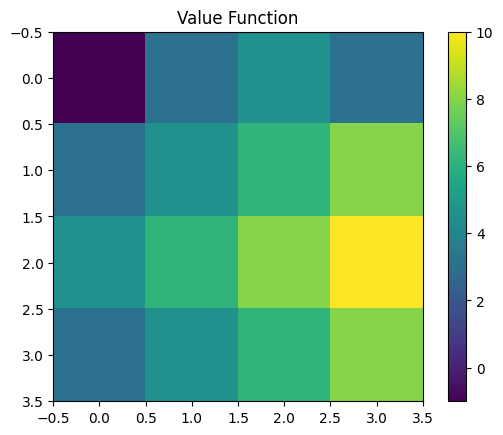

In [ ]:

#EXPERIMENT-8
import numpy as np

r,c=map(int,input("Grid size: ").split())
n=r*c

print("Cells:")
for i in range(1,n+1):
    print(i,end=" ")
    if i%c==0: print()

goal=int(input("Delivery point: "))
obs=list(map(int,input("Obstacles: ").split()))

V=np.zeros(n+1)
moves=[(-1,0),(1,0),(0,-1),(0,1)]

for _ in range(50):
    old=V.copy()

    for s in range(1,n+1):

        if s==goal:
            V[s]=10
            continue

        x,y=(s-1)//c,(s-1)%c
        values=[]

        for dx,dy in moves:
            nx,ny=x+dx,y+dy

            if 0<=nx<r and 0<=ny<c and nx*c+ny+1 not in obs:
                ns=nx*c+ny+1
                values.append(-1+0.9*old[ns])
            else:
                values.append(-1)

        V[s]=max(values)


print("\nState Value Function:")
for i in range(1,n+1):
    print(round(V[i],2),end="\t")
    if i%c==0:
        print()


# Visualization
import matplotlib.pyplot as plt

plt.imshow(V[1:].reshape(r,c),cmap="viridis")
plt.colorbar()
plt.title("Value Function")
plt.show()

In [ ]:
#EXPERIMENT-9
import random

r,c=map(int,input("Road size: ").split())
n=r*c

print("Intersections:")
for i in range(1,n+1):
    print(i,end=" ")
    if i%c==0: print()

dest=int(input("Destination: "))
obs=list(map(int,input("Obstacles: ").split()))

pos=1
moves=[(-1,0),(1,0),(0,-1),(0,1)]
names=["UP","DOWN","LEFT","RIGHT"]

steps=0
reward=0

print("\nCar Route:")

while pos!=dest and steps<50:

    x,y=(pos-1)//c,(pos-1)%c
    choices=[]

    for i,(dx,dy) in enumerate(moves):
        nx,ny=x+dx,y+dy

        if 0<=nx<r and 0<=ny<c:
            ns=nx*c+ny+1
            if ns not in obs:
                choices.append((i,ns))

    action,new= random.choice(choices)

    print("Move:",names[action],"->",new)

    pos=new
    reward-=1
    steps+=1


if pos==dest:
    reward+=10
    print("\nDestination reached safely!")
else:
    print("\nFailed to reach destination")

print("Steps:",steps)
print("Total Reward:",reward)

Road size: 3 4
Intersections:
1 2 3 4 
5 6 7 8 
9 10 11 12 
Destination: 11
Obstacles: 2 6

Car Route:
Move: DOWN -> 5
Move: DOWN -> 9
Move: UP -> 5
Move: DOWN -> 9
Move: RIGHT -> 10
Move: LEFT -> 9
Move: UP -> 5
Move: UP -> 1
Move: DOWN -> 5
Move: UP -> 1
Move: DOWN -> 5
Move: UP -> 1
Move: DOWN -> 5
Move: DOWN -> 9
Move: UP -> 5
Move: UP -> 1
Move: DOWN -> 5
Move: UP -> 1
Move: DOWN -> 5
Move: DOWN -> 9
Move: UP -> 5
Move: UP -> 1
Move: DOWN -> 5
Move: DOWN -> 9
Move: UP -> 5
Move: DOWN -> 9
Move: RIGHT -> 10
Move: LEFT -> 9
Move: RIGHT -> 10
Move: LEFT -> 9
Move: RIGHT -> 10
Move: RIGHT -> 11

Destination reached safely!
Steps: 32
Total Reward: -22


In [ ]:
#EXPERIMENT-10
import random

rep=int(input("Number of representatives: "))
calls=int(input("Number of calls: "))

def monte_carlo(policy):
    value=[0]*rep
    count=[0]*rep

    for _ in range(calls):

        if policy=="Random":
            r=random.randint(0,rep-1)

        else:  # Best available policy
            r=value.index(max(value))

        reward=random.randint(1,10)  # customer satisfaction

        count[r]+=1
        value[r]+= (reward-value[r])/count[r]

    return value


print("\nEstimated Value Function:")

print("Random Policy:",monte_carlo("Random"))
print("Best Assignment Policy:",monte_carlo("Best"))

Number of representatives: 3
Number of calls: 100

Estimated Value Function:
Random Policy: [5.323529411764705, 5.103448275862069, 5.513513513513513]
Best Assignment Policy: [5.53, 0, 0]


In [ ]:
#EXPERIMENT-11
import random

n=int(input("Number of investments: "))
returns=list(map(float,input("Return probabilities: ").split()))
episodes=int(input("Episodes: "))

policy=[1/n]*n
lr=0.1


for _ in range(episodes):

    action=random.choices(range(n),weights=policy)[0]

    reward=random.uniform(-1,1) if random.random()>returns[action] else random.uniform(1,5)

    # Policy Gradient update
    for i in range(n):
        if i==action:
            policy[i]+=lr*reward*(1-policy[i])
        else:
            policy[i]-=lr*reward*policy[i]

    # Normalize
    s=sum(policy)
    policy=[max(0,p/s) for p in policy]


print("\nOptimized Investment Policy:")
for i,p in enumerate(policy):
    print("Investment",i+1,":",round(p,3))

print("Best Investment:",policy.index(max(policy))+1)

Number of investments: 3
Return probabilities: 0.2 0.3 0.7
Episodes: 1000

Optimized Investment Policy:
Investment 1 : 0.0
Investment 2 : 1.0
Investment 3 : 0
Best Investment: 2


In [ ]:
#exp 11
!pip install tensorflow

In [ ]:
#experiment-12
import random
import numpy as np

r,c=map(int,input("House size: ").split())
n=r*c

print("Rooms:")
for i in range(1,n+1):
    print(i,end=" ")
    if i%c==0: print()

dirt=list(map(int,input("Dirty rooms: ").split()))
obs=list(map(int,input("Obstacles: ").split()))
episodes=int(input("Episodes: "))

Q=np.zeros((n+1,4))
moves=[(-1,0),(1,0),(0,-1),(0,1)]
name=["U","D","L","R"]

alpha=0.1
gamma=0.9
eps=0.2


for e in range(episodes):

    state=1
    cleaned=set()

    action=random.randint(0,3)

    while state!=0:

        x,y=(state-1)//c,(state-1)%c
        dx,dy=moves[action]
        nx,ny=x+dx,y+dy

        if nx<0 or nx>=r or ny<0 or ny>=c:
            ns=state
            reward=-2
        else:
            ns=nx*c+ny+1

            if ns in obs:
                ns=state
                reward=-2

            elif ns in dirt and ns not in cleaned:
                cleaned.add(ns)
                reward=5
            else:
                reward=-1


        na=random.randint(0,3) if random.random()<eps else np.argmax(Q[ns])

        Q[state,action]+=alpha*(reward+gamma*Q[ns,na]-Q[state,action])

        state=ns
        action=na

        if len(cleaned)==len(dirt):
            break


print("\nOptimal Cleaning Policy:")
for i in range(1,n+1):
    print(name[np.argmax(Q[i])],end=" ")
    if i%c==0:
        print()

House size: 5 5
Rooms:
1 2 3 4 5 
6 7 8 9 10 
11 12 13 14 15 
16 17 18 19 20 
21 22 23 24 25 
Dirty rooms: 2 9 12 19
Obstacles: 22 25
Episodes: 25

Optimal Cleaning Policy:
R L D D R 
U D R U U 
D U L R U 
D R L R U 
R U R L U 


In [ ]:
#experiment-13
import random
import numpy as np

r,c=map(int,input("Grid size: ").split())
n=r*c

print("Cells:")
for i in range(1,n+1):
    print(i,end=" ")
    if i%c==0: print()

food=int(input("Food cell: "))
ghost=int(input("Ghost cell: "))
episodes=int(input("Episodes: "))

Q=np.zeros((n+1,4))
moves=[(-1,0),(1,0),(0,-1),(0,1)]
name=["U","D","L","R"]

alpha=0.1
gamma=0.9
eps=0.2

for _ in range(episodes):

    state=1

    while state!=food:

        action=random.randint(0,3) if random.random()<eps else np.argmax(Q[state])

        x,y=(state-1)//c,(state-1)%c
        dx,dy=moves[action]

        nx,ny=x+dx,y+dy

        if nx<0 or nx>=r or ny<0 or ny>=c:
            ns=state
            reward=-1
        else:
            ns=nx*c+ny+1

            if ns==food:
                reward=10
            elif ns==ghost:
                reward=-10
                ns=1
            else:
                reward=-1

        Q[state,action]+=alpha*(reward+gamma*max(Q[ns])-Q[state,action])

        state=ns


print("\nLearned Policy:")
for i in range(1,n+1):
    print(name[np.argmax(Q[i])],end=" ")
    if i%c==0: print()

Grid size: 3 3
Cells:
1 2 3 
4 5 6 
7 8 9 
Food cell: 3
Ghost cell: 6
Episodes: 5

Learned Policy:
R R U 
R U U 
U U D 


In [ ]:
#experiment-14
import numpy as np

r,c=map(int,input("Grid size: ").split())
n=r*c

goal=int(input("Goal cell: "))
obs=list(map(int,input("Obstacles: ").split()))

V=np.zeros(n+1)
P=np.zeros(n+1,dtype=int)

moves=[(-1,0),(1,0),(0,-1),(0,1)]
name=["U","D","L","R"]

for _ in range(20):

    # Policy Evaluation
    for _ in range(10):
        for s in range(1,n+1):
            if s==goal:
                V[s]=10
                continue

            x,y=(s-1)//c,(s-1)%c
            dx,dy=moves[P[s]]

            nx,ny=x+dx,y+dy

            if 0<=nx<r and 0<=ny<c and nx*c+ny+1 not in obs:
                V[s]=-1+0.9*V[nx*c+ny+1]


    # Policy Improvement
    for s in range(1,n+1):

        values=[]
        x,y=(s-1)//c,(s-1)%c

        for dx,dy in moves:
            nx,ny=x+dx,y+dy

            if 0<=nx<r and 0<=ny<c and nx*c+ny+1 not in obs:
                values.append(V[nx*c+ny+1])
            else:
                values.append(-99)

        P[s]=np.argmax(values)


print("\nOptimal Policy:")
for i in range(1,n+1):
    print(name[P[i]],end=" ")
    if i%c==0:print()

Grid size: 4 4
Goal cell: 6
Obstacles: 5 9

Optimal Policy:
R D D D 
R U L L 
R U U U 
R U U U 


In [ ]:
#EXPERIMENT-15
import random

rep=int(input("Representatives: "))
calls=int(input("Number of calls: "))
episodes=int(input("Episodes: "))

Q=[0]*rep
count=[0]*rep


for _ in range(episodes):

    total=0

    for i in range(calls):

        agent=random.randint(0,rep-1)

        time=random.randint(1,10)   # call handling time

        reward=-time                # lower time is better

        count[agent]+=1
        Q[agent]+= (reward-Q[agent])/count[agent]

        total+=reward


print("\nAverage Handling Value:")
for i in range(rep):
    print("Representative",i+1,":",round(Q[i],2))

print("Best Representative:",
      Q.index(max(Q))+1)

In [ ]:
#EXPERIMENT-16 : Robot Navigation using Bellman Optimality Equation
import numpy as np

r,c=map(int,input("Grid size: ").split())
n=r*c

goal=int(input("Goal cell: "))
obs=list(map(int,input("Obstacles: ").split()))

V=np.zeros(n+1)
P=[0]*(n+1)

moves=[(-1,0),(1,0),(0,-1),(0,1)]
name=["U","D","L","R"]

for _ in range(50):
    old=V.copy()

    for s in range(1,n+1):

        if s==goal:
            V[s]=10
            continue

        x,y=(s-1)//c,(s-1)%c
        val=[]

        for dx,dy in moves:
            nx,ny=x+dx,y+dy

            if 0<=nx<r and 0<=ny<c and nx*c+ny+1 not in obs:
                val.append(-1+0.9*old[nx*c+ny+1])
            else:
                val.append(-99)

        V[s]=max(val)
        P[s]=np.argmax(val)


print("\nValue Function:")
for i in range(1,n+1):
    print(round(V[i],2),end=" ")
    if i%c==0: print()


print("\nOptimal Path:")
s=1
while s!=goal:
    print(s,end=" -> ")
    x,y=(s-1)//c,(s-1)%c
    dx,dy=moves[P[s]]
    s=(x+dx)*c+y+dy+1
print(goal)

In [ ]:
#EXPERIMENT - 17
import random
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

prices=list(map(int,input("Stock prices: ").split()))
episodes=int(input("Episodes: "))

model=Sequential([
    Dense(16,input_dim=1,activation='relu'),
    Dense(3,activation='linear')
])

target=Sequential.from_config(model.get_config())
target.set_weights(model.get_weights())

model.compile(loss='mse',optimizer='adam')

gamma=0.9

for e in range(episodes):

    profit=0

    for i in range(len(prices)-1):

        state=np.array([[prices[i]]])

        q=model.predict(state,verbose=0)

        epsilon=0.2

        if random.random()<epsilon:
            action=random.randint(0,2)
        else:
            action=np.argmax(q[0])   # 0-Buy 1-Sell 2-Hold

        if action==0:
            reward=prices[i+1]-prices[i]
        elif action==1:
            reward=prices[i]-prices[i+1]
        else:
            reward=0

        next_state=np.array([[prices[i+1]]])

        tq=target.predict(next_state,verbose=0)

        q[0][action]=reward+gamma*np.max(tq)

        model.fit(state,q,epochs=1,verbose=0)

        profit+=reward

    target.set_weights(model.get_weights())

    print("Episode",e+1,"Profit:",profit)

print("\nPolicy:")
print("0 = Buy")
print("1 = Sell")
print("2 = Hold")

Stock prices: 30 40 130 70 90
Episodes: 6
Episode 1 Profit: 100
Episode 2 Profit: 20
Episode 3 Profit: 40
Episode 4 Profit: 120
Episode 5 Profit: 120
Episode 6 Profit: 50

Policy:
0 = Buy
1 = Sell
2 = Hold


In [1]:
#EXP - 18
import numpy as np

np.random.seed(1)

prices = np.array([100, 102, 101, 105, 108, 107, 111, 115, 114, 118])
returns = np.diff(prices) / prices[:-1]

actor = np.array([0.5, 0.5])
critic = 0.0
lr = 0.05
gamma = 0.9

for episode in range(100):
    wealth = 1000
    state = 0

    for r in returns:
        action_prob = actor / actor.sum()
        action = np.random.choice([0, 1], p=action_prob)

        reward = r * wealth if action == 0 else -r * wealth
        next_state = state + 1

        target = reward + gamma * critic
        advantage = target - critic

        actor[action] += lr * advantage
        critic += lr * advantage

        actor = np.maximum(actor, 0.01)
        state = next_state
        wealth += reward

print("Stock Investment Preference:", actor / actor.sum())
print("Final Portfolio Value:", round(wealth, 2))

Stock Investment Preference: [9.99950192e-01 4.98083565e-05]
Final Portfolio Value: 1180.0


In [2]:
#EXP 19
import numpy as np

np.random.seed(1)

actor = np.ones((3,4))
critic = np.zeros(3)

lr = 0.05
gamma = 0.9

for episode in range(500):
    resources = 10
    state = 0

    for step in range(30):
        probs = actor[state] / actor[state].sum()
        action = np.random.choice(4, p=probs)

        if action == 0:
            reward = 5
            resources += 5
            next_state = 0
        elif action == 1:
            reward = 8 if resources >= 10 else -5
            resources -= 10 if resources >= 10 else 0
            next_state = 1
        elif action == 2:
            reward = 10 if resources >= 15 else -5
            resources -= 15 if resources >= 15 else 0
            next_state = 2
        else:
            reward = 15 if resources >= 20 else -8
            resources -= 20 if resources >= 20 else 0
            next_state = 2

        target = reward + gamma * critic[next_state]
        advantage = target - critic[state]

        actor[state,action] += lr * advantage
        critic[state] += lr * advantage

        actor = np.maximum(actor, 0.01)
        state = next_state

print("Learned Strategy:")
for s in range(3):
    print("State", s, "Best Action:", np.argmax(actor[s]))

Learned Strategy:
State 0 Best Action: 1
State 1 Best Action: 0
State 2 Best Action: 0


In [3]:
#EXP 20
import numpy as np

np.random.seed(1)

actor = np.ones((3,3))
critic = np.zeros(3)

lr = 0.05
gamma = 0.9

for episode in range(500):
    speed = 1
    state = 1

    for step in range(30):
        probs = actor[state] / actor[state].sum()
        action = np.random.choice(3, p=probs)

        if action == 0:
            speed -= 1
            reward = 1
        elif action == 1:
            reward = 3
        else:
            speed += 1
            reward = 5 if speed <= 3 else -8

        speed = max(1, min(speed, 4))
        next_state = min(speed - 1, 2)

        target = reward + gamma * critic[next_state]
        advantage = target - critic[state]

        actor[state,action] += lr * advantage
        critic[state] += lr * advantage

        actor = np.maximum(actor, 0.01)
        state = next_state

print("Racing Policy:")
print("0 = Brake, 1 = Maintain, 2 = Accelerate")

for state in range(3):
    print("State", state, "Best Action:", np.argmax(actor[state]))

Racing Policy:
0 = Brake, 1 = Maintain, 2 = Accelerate
State 0 Best Action: 2
State 1 Best Action: 2
State 2 Best Action: 1


In [4]:
#EXP - 21
import numpy as np

np.random.seed(1)

actions = ["Story", "Joke", "Question", "Interaction"]
policy = np.ones(4) / 4
lr = 0.05

for episode in range(500):
    probs = policy / policy.sum()
    action = np.random.choice(4, p=probs)

    rewards = [8, 6, 7, 10]
    reward = rewards[action]

    for i in range(4):
        if i == action:
            policy[i] += lr * reward * (1 - probs[i])
        else:
            policy[i] -= lr * reward * probs[i]

    policy = np.maximum(policy, 0.01)

print("Learned Content Policy:")

for i in range(4):
    print(actions[i], ":", round(policy[i] / policy.sum(), 2))

Learned Content Policy:
Story : 0.99
Joke : 0.0
Question : 0.0
Interaction : 0.0


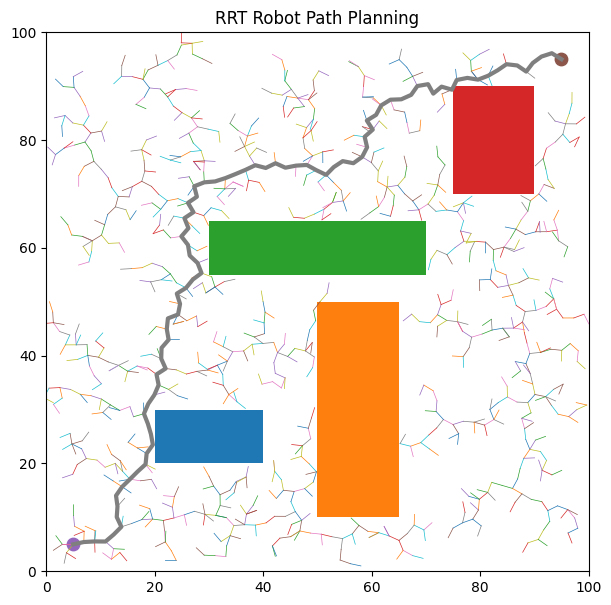

In [5]:
#EXP - 22
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

start = np.array([5,5])
goal = np.array([95,95])

obstacles = [
    (20,20,40,30),
    (50,10,65,50),
    (30,55,70,65),
    (75,70,90,90)
]

nodes = [start]
parents = [-1]

def collision(p):
    for x1,y1,x2,y2 in obstacles:
        if x1 <= p[0] <= x2 and y1 <= p[1] <= y2:
            return True
    return False

for i in range(3000):
    sample = np.random.randint(0,101,2)

    distances = [np.linalg.norm(n-sample) for n in nodes]
    nearest = np.argmin(distances)

    direction = sample - nodes[nearest]
    direction = direction / np.linalg.norm(direction)

    new_node = nodes[nearest] + direction * 2

    if not collision(new_node):
        nodes.append(new_node)
        parents.append(nearest)

        if np.linalg.norm(new_node-goal) < 3:
            nodes.append(goal)
            parents.append(len(nodes)-2)
            break

path = []
index = len(nodes)-1

while index != -1:
    path.append(nodes[index])
    index = parents[index]

path = path[::-1]

plt.figure(figsize=(7,7))

for x1,y1,x2,y2 in obstacles:
    plt.fill([x1,x2,x2,x1],[y1,y1,y2,y2])

for i in range(1,len(nodes)):
    plt.plot(
        [nodes[i][0],nodes[parents[i]][0]],
        [nodes[i][1],nodes[parents[i]][1]],
        linewidth=0.5
    )

path = np.array(path)
plt.plot(path[:,0],path[:,1],linewidth=3)

plt.scatter(start[0],start[1],s=80)
plt.scatter(goal[0],goal[1],s=80)

plt.xlim(0,100)
plt.ylim(0,100)
plt.title("RRT Robot Path Planning")
plt.show()

In [6]:
#EXP- 23
import numpy as np

np.random.seed(1)

inventory = 20
capacity = 30

def demand():
    return np.random.randint(5,16)

def simulate(order):
    global inventory

    inventory = min(capacity, inventory + order)
    d = demand()

    sold = min(inventory, d)
    inventory -= sold

    reward = sold * 10 - order * 4 - inventory * 1

    if d > sold:
        reward -= (d-sold) * 5

    return reward

policies = {
    "Low Order": 5,
    "Medium Order": 10,
    "High Order": 15
}

results = {}

for name, order in policies.items():
    total = 0
    inventory = 20

    for day in range(100):
        total += simulate(order)

    results[name] = total

print("Inventory Policy Performance:")

for name, value in results.items():
    print(name, ":", round(value,2))

print("\nBest Policy:", max(results, key=results.get))

Inventory Policy Performance:
Low Order : 623
Medium Order : 4335
High Order : 1901

Best Policy: Medium Order


In [7]:
#EXP - 24
import numpy as np

np.random.seed(1)

returns = np.array([
    [0.08, 0.04, 0.02],
    [0.06, 0.06, 0.03],
    [0.10, 0.03, 0.01],
    [0.05, 0.07, 0.02],
    [0.09, 0.05, 0.03],
    [0.07, 0.06, 0.02]
])

portfolios = {
    "Growth": [0.7,0.2,0.1],
    "Balanced": [0.5,0.3,0.2],
    "Safe": [0.2,0.3,0.5]
}

initial = 10000
years = 5

for name, weights in portfolios.items():

    portfolio_return = np.mean(returns @ np.array(weights))

    predicted_value = initial * (1 + portfolio_return) ** years

    risk = np.std(returns @ np.array(weights))

    print(name)
    print("Expected Return:", round(portfolio_return*100,2), "%")
    print("Risk:", round(risk,4))
    print("Predicted Value:", round(predicted_value,2))
    print()

Growth
Expected Return: 6.5 %
Risk: 0.0094
Predicted Value: 13700.87

Balanced
Expected Return: 5.73 %
Risk: 0.0051
Predicted Value: 13214.77

Safe
Expected Return: 4.13 %
Risk: 0.0045
Predicted Value: 12244.72



In [8]:
#EXP - 25
import numpy as np

np.random.seed(1)

prices = np.array([10,15,20,25,30])
base_demand = 100

sales = []

for p in prices:
    demand = base_demand - 2*p + np.random.randint(-5,6)
    sales.append(max(0,demand))

sales = np.array(sales)

a,b = np.polyfit(prices,sales,1)

print("Demand Model:")
print("Demand =", round(a,2), "* Price +", round(b,2))

best_price = 0
best_profit = 0

for price in np.arange(5,41,1):

    predicted_demand = max(0,a*price+b)
    profit = price * predicted_demand

    if profit > best_profit:
        best_profit = profit
        best_price = price

print("\nOptimal Price:", best_price)
print("Predicted Demand:", round(a*best_price+b,2))
print("Maximum Profit:", round(best_profit,2))

Demand Model:
Demand = -2.26 * Price + 105.6

Optimal Price: 23
Predicted Demand: 53.62
Maximum Profit: 1233.26


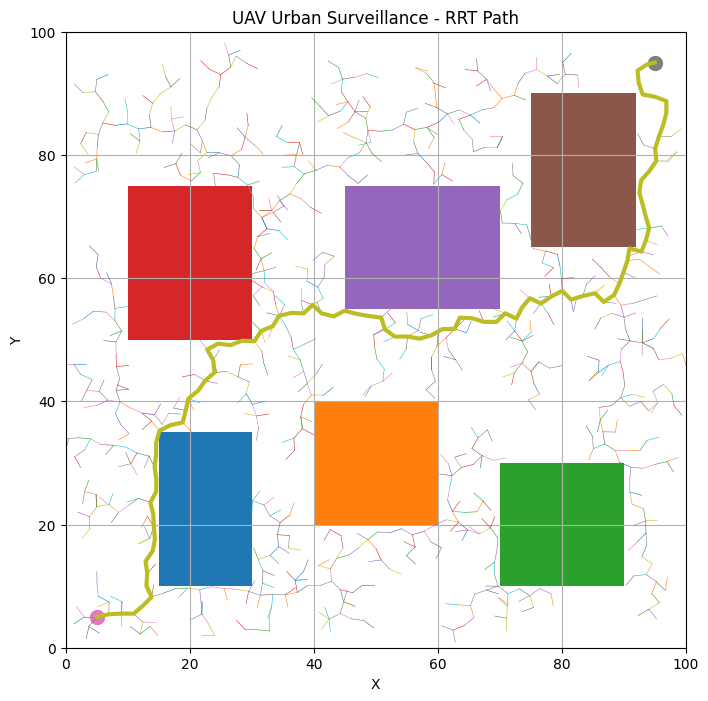

Path Points: 92
Path Length: 181.11
Surveillance mission completed!


In [9]:
#EXP- 26
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

start = np.array([5, 5])
goal = np.array([95, 95])

buildings = [
    (15, 10, 30, 35),
    (40, 20, 60, 40),
    (70, 10, 90, 30),
    (10, 50, 30, 75),
    (45, 55, 70, 75),
    (75, 65, 92, 90)
]

nodes = [start]
parents = [-1]

def collision(p):
    for x1, y1, x2, y2 in buildings:
        if x1 <= p[0] <= x2 and y1 <= p[1] <= y2:
            return True
    return False

for _ in range(4000):

    sample = np.random.randint(0, 101, 2)

    distances = [np.linalg.norm(n - sample) for n in nodes]
    nearest = np.argmin(distances)

    direction = sample - nodes[nearest]
    length = np.linalg.norm(direction)

    if length == 0:
        continue

    direction = direction / length
    new_node = nodes[nearest] + direction * 2

    if not collision(new_node):
        nodes.append(new_node)
        parents.append(nearest)

        if np.linalg.norm(new_node - goal) < 3:
            nodes.append(goal)
            parents.append(len(nodes) - 2)
            break

path = []
i = len(nodes) - 1

while i != -1:
    path.append(nodes[i])
    i = parents[i]

path = np.array(path[::-1])

plt.figure(figsize=(8, 8))

for x1, y1, x2, y2 in buildings:
    plt.fill([x1,x2,x2,x1], [y1,y1,y2,y2])

for i in range(1, len(nodes)):
    plt.plot(
        [nodes[i][0], nodes[parents[i]][0]],
        [nodes[i][1], nodes[parents[i]][1]],
        linewidth=0.4
    )

plt.plot(path[:,0], path[:,1], linewidth=3)
plt.scatter(start[0], start[1], s=100)
plt.scatter(goal[0], goal[1], s=100)

plt.title("UAV Urban Surveillance - RRT Path")
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(0,100)
plt.ylim(0,100)
plt.grid()
plt.show()

print("Path Points:", len(path))
print("Path Length:", round(sum(np.linalg.norm(path[i]-path[i-1]) for i in range(1,len(path))),2))
print("Surveillance mission completed!")

In [10]:
#EXP- 27
import numpy as np

np.random.seed(1)

inventory = 50
capacity = 100

def demand():
    return np.random.randint(10, 31)

def simulate(order):
    global inventory

    inventory = min(capacity, inventory + order)

    d = demand()
    sold = min(inventory, d)

    inventory -= sold

    transport_cost = order * 2
    holding_cost = inventory
    shortage_cost = (d - sold) * 5

    reward = sold * 10 - transport_cost - holding_cost - shortage_cost

    return reward

policies = {
    "Low Supply": 10,
    "Medium Supply": 25,
    "High Supply": 40
}

results = {}

for name, order in policies.items():

    inventory = 50
    total_reward = 0

    for day in range(100):
        total_reward += simulate(order)

    results[name] = total_reward

print("Supply Chain Policy Results\n")

for name, reward in results.items():
    print(name, ":", round(reward,2))

print("\nBest Policy:", max(results, key=results.get))

Supply Chain Policy Results

Low Supply : 3685
Medium Supply : 7410
High Supply : 5044

Best Policy: Medium Supply


In [11]:
#EXP- 28
import numpy as np

np.random.seed(1)

q_get = np.zeros((3,2))
q_deliver = np.zeros((3,2))

lr = 0.1
gamma = 0.9

for episode in range(500):

    position = 0
    package = 0
    total_reward = 0

    for step in range(20):

        if package == 0:

            action = np.argmax(q_get[position])

            if action == 0:
                position = min(position + 1, 2)
                reward = 2
            else:
                position = max(position - 1, 0)
                reward = -1

            if position == 2:
                package = 1
                reward += 10

            q_get[position, action] += lr * (
                reward + gamma * np.max(q_get[position])
                - q_get[position, action]
            )

        else:

            action = np.argmax(q_deliver[position])

            if action == 0:
                position = max(position - 1, 0)
                reward = 2
            else:
                position = min(position + 1, 2)
                reward = -1

            if position == 0:
                reward += 20
                package = 0

            q_deliver[position, action] += lr * (
                reward + gamma * np.max(q_deliver[position])
                - q_deliver[position, action]
            )

        total_reward += reward

print("MAXQ Hierarchical Policies")

print("Get Package Policy:")
print(np.argmax(q_get, axis=1))

print("\nDeliver Package Policy:")
print(np.argmax(q_deliver, axis=1))

print("\nFinal Episode Reward:", total_reward)

MAXQ Hierarchical Policies
Get Package Policy:
[0 0 0]

Deliver Package Policy:
[0 0 0]

Final Episode Reward: 190


Learned Meta Parameter: 0.7558
Final Control Error: 0.0


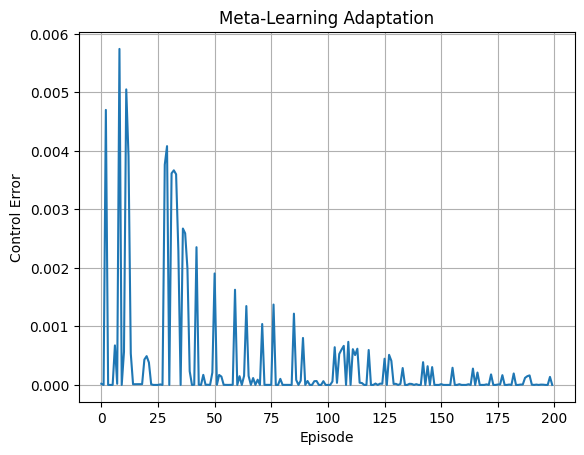

In [12]:
#EXP- 29
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

conditions = [1.0, 1.5, 2.0, 2.5]

meta_parameter = 0.5
lr = 0.1

history = []

for episode in range(200):

    condition = np.random.choice(conditions)

    target = 10
    state = np.random.uniform(0, 5)

    parameter = meta_parameter

    for step in range(30):

        control = parameter * (target - state)

        state += control / condition

        error = target - state

        parameter += lr * error * 0.01

    performance = abs(target - state)

    meta_parameter = 0.9 * meta_parameter + 0.1 * parameter

    history.append(performance)

print("Learned Meta Parameter:", round(meta_parameter,4))
print("Final Control Error:", round(history[-1],4))

plt.plot(history)
plt.xlabel("Episode")
plt.ylabel("Control Error")
plt.title("Meta-Learning Adaptation")
plt.grid()
plt.show()

In [13]:
#EXP- 30
import numpy as np

np.random.seed(1)

robots = 3
targets = np.array([2, 5, 8])

q = np.zeros((robots, 10, 2))

lr = 0.1
gamma = 0.9

for episode in range(500):

    positions = np.random.randint(0, 10, robots)
    collected = set()

    for step in range(30):

        actions = []

        for r in range(robots):

            state = positions[r]
            action = np.argmax(q[r,state])

            if np.random.rand() < 0.1:
                action = np.random.randint(2)

            actions.append(action)

        total_reward = 0

        for r in range(robots):

            if actions[r] == 0:
                positions[r] = max(0, positions[r] - 1)
            else:
                positions[r] = min(9, positions[r] + 1)

            reward = -1

            for t in targets:

                if positions[r] == t and t not in collected:
                    reward = 20
                    collected.add(t)

            total_reward += reward

            state = positions[r]

            q[r,state,actions[r]] += lr * (
                reward +
                gamma * np.max(q[r,state])
                - q[r,state,actions[r]]
            )

        if len(collected) == len(targets):
            break

print("Targets:", targets)
print("Collected Targets:", sorted(collected))
print("Number of Robots:", robots)
print("Mission Completed:", len(collected) == len(targets))

Targets: [2 5 8]
Collected Targets: [np.int64(5), np.int64(8)]
Number of Robots: 3
Mission Completed: False
